# Clustering des phases d'exploration — K-Prototypes

**Objectif** : regrouper les phases de contrats selon leur profil **au début de la phase**, puis interpréter les groupes avec les résultats (avancement physique, volume 2P, R/I).

**Règles du projet (CLAUDE.md §2.2)** :
- **Construire** les clusters uniquement avec `ml.features_clustering`, qui ne contient que des informations connues au début de la phase.
- **Interpréter** ensuite avec `ml.vw_phase_outcomes` (colonnes `out_*`). Les outcomes ne doivent **jamais** entrer dans le clustering.
- Les données sont majoritairement **synthétiques** : les structures trouvées sont celles que le générateur y a mises.

**Comment utiliser ce notebook** : les cellules marquées **`TODO`** contiennent des choix à faire. Elles s'arrêtent (`assert`) tant que le choix n'est pas fait. Les autres cellules sont prêtes à l'emploi.

Pourquoi K-Prototypes : les features mélangent des variables **numériques** (coûts, distances, volumes) et **catégorielles** (classification, type de contrat…). K-Prototypes combine K-Means (moyennes, numériques) et K-Modes (modes, catégorielles). Le poids relatif des deux parties est réglé par le paramètre `gamma`.

## 0. Installation et connexion

In [1]:
# Dépendances (une seule fois, dans le .venv du projet) :
#   pip install kmodes gower scikit-learn matplotlib
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gower
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, adjusted_rand_score

from src.db import get_conn          # lit SUPABASE_DB_URL dans .env

GRAINE = 20260928                    # pour des résultats reproductibles
pd.set_option("display.max_columns", 50)

## 1. Chargement des features

In [2]:
def lire_sql(requete: str) -> pd.DataFrame:
    with get_conn() as conn:
        cur = conn.execute(requete)
        df = pd.DataFrame(cur.fetchall(), columns=[d.name for d in cur.description])
    # numeric PostgreSQL -> float
    for c in df.columns:
        if df[c].map(type).astype(str).str.contains("Decimal").any():
            df[c] = df[c].astype(float)
    return df

features = lire_sql("select * from ml.features_clustering order by sk_phase").set_index("sk_phase")
print(features.shape)
features.head()

(495, 26)


,cout_puits_wildcat,cout_puits_delineation,cout_acquisition_sismique_2d,cout_acquisition_sismique_3d,cout_retraitement_2d,cout_retraitement_3d,part_sismique_engagee,cout_hist_par_km_2d,cout_hist_par_km2_3d,cout_hist_par_puits,budget_pmt_mensuel_estime,classification,distance_gisement_km,situation_debut_phase,superficie_initiale,type_contrat,partenariat,operateur,numero_phase,anciennete_contrat_jours,puits_wildcat,puits_delineation,acquisition_sismique_2d_km,acquisition_sismique_3d_km2,nb_decouvertes_anterieures_departement,nb_decouvertes_anterieures_asset
sk_phase,,,,,,,,,,,,,,,,,,,,,,,,,,
100002,1151157.20,1314919.17,0.00,972354.99,0.0,37863.08,0.290602,348.935917,775.784049,467513.20,15285.655269,NEAR FIELD EMERGEANT,14.281667,EV,1184.72,CONTRAT DE RECHERCHE,EFFORT PROPRE,SONATRACH,2,977,2,2,0.00,1010.24,1,1
100003,1002821.47,0.00,629626.90,1682926.40,0.0,75494.60,0.704258,348.935917,775.784049,467513.20,0.000000,FRONTIER MATURE,75.091747,EV,2010.67,CONCESSION AMONT,EFFORT PROPRE,SONATRACH,1,0,2,0,1589.97,1748.49,1,1
100016,573076.48,1232492.95,317394.74,981543.12,0.0,0.00,0.418404,500.442776,868.476150,469577.99,5546.574106,NON RENSEIGNE,22.728757,EV,1898.90,CONTRAT DE RECHERCHE,PARTENARIAT,PARTENAIRE 07,2,1134,1,2,928.05,1180.80,1,1
100017,2352348.40,1520672.95,0.00,0.00,0.0,0.00,0.000000,437.454033,868.476150,276177.67,14764.073609,UNKNOWN,15.858607,EV,2377.22,CONTRAT DE RECHERCHE,EFFORT PROPRE,SONATRACH,2,1109,5,3,0.00,0.00,1,2
100018,857455.05,0.00,0.00,822505.10,0.0,36420.17,0.500428,401.700560,868.476150,276177.67,39618.428980,NEAR FIELD EMERGEANT,158.091615,EV,1492.81,CONTRAT DE RECHERCHE,PARTENARIAT,PARTENAIRE 01,2,1323,2,0,0.00,940.01,1,2


## 2. Exploration

In [3]:
CATEGORIELLES_DISPO = features.select_dtypes(include=["object", "bool"]).columns.tolist()
NUMERIQUES_DISPO = features.select_dtypes(include="number").columns.tolist()
print("Catégorielles :", CATEGORIELLES_DISPO)
print("Numériques    :", NUMERIQUES_DISPO)
features[NUMERIQUES_DISPO].describe().T

Catégorielles : ['classification', 'situation_debut_phase', 'type_contrat', 'partenariat', 'operateur']
Numériques    : ['cout_puits_wildcat', 'cout_puits_delineation', 'cout_acquisition_sismique_2d', 'cout_acquisition_sismique_3d', 'cout_retraitement_2d', 'cout_retraitement_3d', 'part_sismique_engagee', 'cout_hist_par_km_2d', 'cout_hist_par_km2_3d', 'cout_hist_par_puits', 'budget_pmt_mensuel_estime', 'distance_gisement_km', 'superficie_initiale', 'numero_phase', 'anciennete_contrat_jours', 'puits_wildcat', 'puits_delineation', 'acquisition_sismique_2d_km', 'acquisition_sismique_3d_km2', 'nb_decouvertes_anterieures_departement', 'nb_decouvertes_anterieures_asset']


C:\Users\samsung\AppData\Local\Temp\ipykernel_28000\3740225655.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CATEGORIELLES_DISPO = features.select_dtypes(include=["object", "bool"]).columns.tolist()


,count,mean,std,min,25%,50%,75%,max
cout_puits_wildcat,495.0,1.297804e+06,842173.381755,0.000000,596517.190000,1.188365e+06,1.813830e+06,4.951423e+06
cout_puits_delineation,495.0,3.446631e+05,525288.194369,0.000000,0.000000,0.000000e+00,5.690966e+05,2.413233e+06
cout_acquisition_sismique_2d,495.0,1.665147e+05,245979.903306,0.000000,0.000000,0.000000e+00,3.184601e+05,1.368000e+06
cout_acquisition_sismique_3d,495.0,2.455828e+05,356393.061050,0.000000,0.000000,0.000000e+00,4.698348e+05,1.968750e+06
cout_retraitement_2d,495.0,8.620094e+03,18349.549455,0.000000,0.000000,0.000000e+00,0.000000e+00,1.117444e+05
cout_retraitement_3d,495.0,3.151225e+03,10327.761265,0.000000,0.000000,0.000000e+00,0.000000e+00,7.549460e+04
part_sismique_engagee,495.0,2.352855e-01,0.261410,0.000000,0.000000,1.619860e-01,3.687612e-01,1.000000e+00
cout_hist_par_km_2d,495.0,4.278148e+02,56.582504,327.838251,386.627729,4.175723e+02,4.642983e+02,5.886080e+02
cout_hist_par_km2_3d,495.0,1.110250e+03,770.310656,709.207527,904.601063,9.995636e+02,1.144785e+03,8.767894e+03
cout_hist_par_puits,495.0,5.335144e+05,97299.540609,276177.670000,476729.261000,5.388847e+05,5.599126e+05,9.887915e+05


In [4]:
for c in CATEGORIELLES_DISPO:
    print(features[c].value_counts().to_dict())

{'NEAR FIELD EMERGEANT': 207, 'FRONTIER EMERGEANT': 99, 'NEAR FIELD MATURE': 66, 'FRONTIER MATURE': 60, 'UNKNOWN': 44, 'NON RENSEIGNE': 19}
{'EV': 472, 'EPR': 23}
{'CONTRAT DE RECHERCHE': 313, 'CONCESSION AMONT': 182}
{'EFFORT PROPRE': 255, 'PARTENARIAT': 240}
{'SONATRACH': 298, 'PARTENAIRE 08': 42, 'PARTENAIRE 04': 34, 'PARTENAIRE 03': 27, 'PARTENAIRE 07': 24, 'PARTENAIRE 01': 24, 'PARTENAIRE 05': 22, 'PARTENAIRE 06': 18, 'PARTENAIRE 02': 6}


In [5]:
# Asymétrie des variables numériques : une forte asymétrie (> 1) suggère une transformation log.
features[NUMERIQUES_DISPO].skew().sort_values(ascending=False)

cout_hist_par_km2_3d                      7.614448
distance_gisement_km                      3.616072
cout_retraitement_3d                      3.604468
budget_pmt_mensuel_estime                 2.871945
cout_retraitement_2d                      2.368573
superficie_initiale                       2.008196
cout_hist_par_puits                       1.542771
acquisition_sismique_3d_km2               1.525912
cout_puits_delineation                    1.522981
nb_decouvertes_anterieures_departement    1.517544
acquisition_sismique_2d_km                1.495116
cout_acquisition_sismique_2d              1.485901
cout_acquisition_sismique_3d              1.457230
puits_delineation                         1.439413
part_sismique_engagee                     1.313780
cout_hist_par_km_2d                       0.904853
nb_decouvertes_anterieures_asset          0.849402
cout_puits_wildcat                        0.692263
numero_phase                              0.598566
anciennete_contrat_jours       

In [6]:
# Corrélations entre numériques : deux variables très corrélées (|r| > 0.8) comptent « deux fois ».
corr = features[NUMERIQUES_DISPO].corr()
fortes = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
fortes[fortes.abs() > 0.8].sort_values()

nb_decouvertes_anterieures_departement  nb_decouvertes_anterieures_asset    0.815444
cout_puits_wildcat                      puits_wildcat                       0.945858
numero_phase                            anciennete_contrat_jours            0.977738
cout_puits_delineation                  puits_delineation                   0.984280
cout_acquisition_sismique_3d            acquisition_sismique_3d_km2         0.994804
cout_acquisition_sismique_2d            acquisition_sismique_2d_km          0.995074
dtype: float64

## 3. Préparation — **TODO : vos choix**

À décider, en vous appuyant sur l'exploration :
1. **Colonnes retenues.** Les coûts engagés détaillés et les volumes engagés décrivent le même programme : tout garder donne beaucoup de poids aux coûts. Les catégorielles à nombreuses modalités (`departement`, `operateur`) pèsent aussi.
2. **Transformation log** des variables très asymétriques (coûts, distance, budget). `np.log1p` gère les zéros.
3. Les numériques sont ensuite **standardisées** (moyenne 0, écart-type 1) : c'est nécessaire pour K-Prototypes.

In [7]:
# Choix (exploration ci-dessus) :
# - Coûts et volumes engagés sont quasi identiques (r = 0,95 à 1,00 entre chaque coût et son volume) :
#   on ne garde PAS les deux. On résume le programme par sa taille (coût engagé total), sa composition
#   (part sismique) et ses puits (wildcat / délinéation).
# - numero_phase et anciennete_contrat_jours : r = 0,98 -> on garde numero_phase.
# - nb découvertes département / asset : r = 0,82 -> on garde le département (plus local).
# - Catégorielles : les 5 de la liste. operateur apporte l'identité du partenaire (effet compagnie),
#   en plus de partenariat.
features["cout_engage_total"] = features[["cout_puits_wildcat", "cout_puits_delineation", "cout_acquisition_sismique_2d",
                                          "cout_acquisition_sismique_3d", "cout_retraitement_2d", "cout_retraitement_3d"]].sum(axis=1)

CATEGORIELLES = ["classification", "type_contrat", "partenariat", "operateur", "situation_debut_phase"]
NUMERIQUES = ["cout_engage_total", "part_sismique_engagee", "puits_wildcat", "puits_delineation", "numero_phase",
              "distance_gisement_km", "superficie_initiale", "nb_decouvertes_anterieures_departement",
              "cout_hist_par_puits", "cout_hist_par_km_2d", "cout_hist_par_km2_3d", "budget_pmt_mensuel_estime"]

# Log1p pour les variables les plus asymétriques (asymétrie > 1,5 ou valeurs extrêmes)
A_LOGUER = ["cout_engage_total", "distance_gisement_km", "superficie_initiale", "nb_decouvertes_anterieures_departement",
            "cout_hist_par_km2_3d", "budget_pmt_mensuel_estime"]

# Poids de la partie catégorielle. Avec 12 numériques standardisées, la valeur par défaut de kmodes
# (0,5) laisse dominer les numériques ; gamma = 1 donne à chaque catégorielle à peu près le poids
# d'une numérique. Les résultats sont peu sensibles à gamma pour K <= 4 (vérifié en section 5).
GAMMA = 1.0

assert CATEGORIELLES is not None and NUMERIQUES is not None and A_LOGUER is not None, "Faites vos choix de colonnes (TODO 1 et 2)"
assert set(A_LOGUER) <= set(NUMERIQUES)
assert not any(c.startswith("out_") for c in CATEGORIELLES + NUMERIQUES), "Jamais d'outcome dans le clustering"

In [8]:
def preparer(df: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame, list[int]]:
    """Renvoie (matrice pour K-Prototypes, tableau pour Gower, indices des colonnes catégorielles)."""
    num = df[NUMERIQUES].astype(float).copy()
    for c in A_LOGUER:
        num[c] = np.log1p(num[c])
    num_std = (num - num.mean()) / num.std(ddof=0)
    cat = df[CATEGORIELLES].astype(str)
    tableau = pd.concat([num_std, cat], axis=1)
    idx_cat = list(range(len(NUMERIQUES), len(NUMERIQUES) + len(CATEGORIELLES)))
    return tableau.to_numpy(dtype=object), tableau, idx_cat

X, tableau, IDX_CAT = preparer(features)
print(X.shape, "| colonnes catégorielles aux positions", IDX_CAT)
tableau.head()

(495, 17) | colonnes catégorielles aux positions [12, 13, 14, 15, 16]


,cout_engage_total,part_sismique_engagee,puits_wildcat,puits_delineation,numero_phase,distance_gisement_km,superficie_initiale,nb_decouvertes_anterieures_departement,cout_hist_par_puits,cout_hist_par_km_2d,cout_hist_par_km2_3d,budget_pmt_mensuel_estime,classification,type_contrat,partenariat,operateur,situation_debut_phase
sk_phase,,,,,,,,,,,,,,,,,
100002,1.063259,0.211822,-0.231305,1.472475,0.203048,-0.362745,-1.339139,-1.627487,-0.679016,-1.395462,-0.953352,1.039031,NEAR FIELD EMERGEANT,CONTRAT DE RECHERCHE,EFFORT PROPRE,SONATRACH,EV
100003,1.025034,1.795830,-0.231305,-0.668127,-0.993484,0.808542,-0.485474,-1.627487,-0.679016,-1.395462,-0.953352,-0.905778,FRONTIER MATURE,CONCESSION AMONT,EFFORT PROPRE,SONATRACH,EV
100016,0.889483,0.701212,-0.925220,1.472475,0.203048,-0.041677,-0.577789,-1.627487,-0.657774,1.284874,-0.575510,0.834428,NON RENSEIGNE,CONTRAT DE RECHERCHE,PARTENARIAT,PARTENAIRE 07,EV
100017,1.229285,-0.900975,1.850439,2.542776,0.203048,-0.291088,-0.215159,-1.627487,-2.647464,0.170529,-0.575510,1.032023,UNKNOWN,CONTRAT DE RECHERCHE,EFFORT PROPRE,SONATRACH,EV
100018,-0.020995,1.015307,-0.231305,-0.668127,0.203048,1.346683,-0.966128,-1.627487,-2.647464,-0.461993,-0.575510,1.231264,NEAR FIELD EMERGEANT,CONTRAT DE RECHERCHE,PARTENARIAT,PARTENAIRE 01,EV


## 4. Outils : silhouette (distance de Gower) et coût

- **Coût** de K-Prototypes : diminue toujours quand K augmente ; on cherche un « coude ».
- **Silhouette** sur la distance de Gower (adaptée aux données mixtes) : entre −1 et 1, plus c'est haut mieux les groupes sont séparés.

In [9]:
# Matrice de Gower (calculée une fois) : distances entre phases, en mélangeant numériques et catégorielles
est_cat = [False] * len(NUMERIQUES) + [True] * len(CATEGORIELLES)
D_GOWER = gower.gower_matrix(tableau, cat_features=est_cat)
print(D_GOWER.shape)

def ajuster(k: int, gamma=None, n_init: int = 5, graine: int = GRAINE, donnees=None) -> KPrototypes:
    modele = KPrototypes(n_clusters=k, init="Cao", n_init=n_init, gamma=GAMMA if gamma is None else gamma, random_state=graine, n_jobs=1)
    modele.fit(X if donnees is None else donnees, categorical=IDX_CAT)
    return modele

def silhouette_gower(etiquettes: np.ndarray, D: np.ndarray = None) -> float:
    D = D_GOWER if D is None else D
    if len(set(etiquettes)) < 2:
        return float("nan")
    return float(silhouette_score(D, etiquettes, metric="precomputed"))

(495, 495)


## 5. Choix du nombre de clusters K — **TODO**

Testez plusieurs K (par exemple de 2 à 8). **Ne forcez pas K = 4** sous prétexte que la grille théorique a 4 classes : c'est justement ce qu'on veut comparer ensuite.

In [10]:
# TODO 3 : valeurs de K à tester
K_A_TESTER = range(2, 9)
assert K_A_TESTER is not None, "Choisissez les valeurs de K à tester (TODO 3)"

resultats_k = []
for k in K_A_TESTER:
    m = ajuster(k)
    resultats_k.append({"k": k, "cout": m.cost_, "silhouette_gower": silhouette_gower(m.labels_),
                        "taille_min": int(np.bincount(m.labels_).min()), "gamma": m.gamma})
resultats_k = pd.DataFrame(resultats_k).set_index("k")
resultats_k

,cout,silhouette_gower,taille_min,gamma
k,,,,
2,5885.123268,0.161795,239,1.0
3,5236.139720,0.141396,87,1.0
4,4902.916171,0.125681,78,1.0
5,4623.663931,0.130472,10,1.0
6,4360.250206,0.091130,10,1.0
7,4122.969227,0.088795,10,1.0
8,3898.756051,0.089790,10,1.0


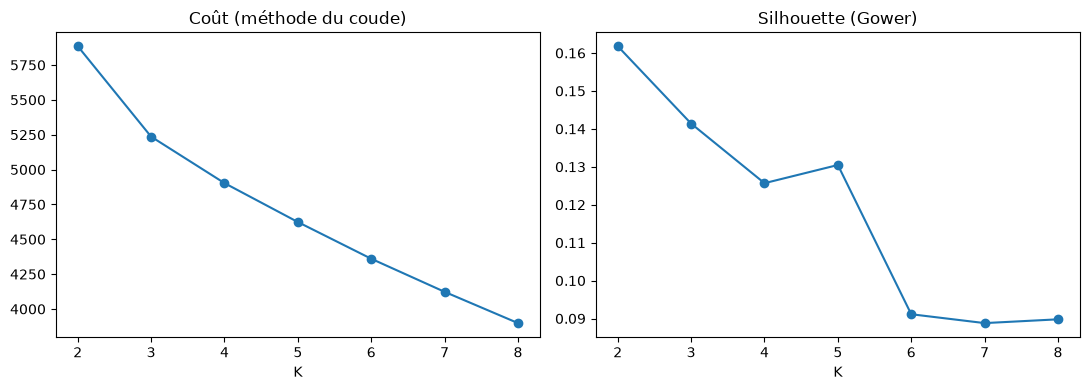

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
resultats_k["cout"].plot(ax=axes[0], marker="o", title="Coût (méthode du coude)")
resultats_k["silhouette_gower"].plot(ax=axes[1], marker="o", title="Silhouette (Gower)")
for a in axes:
    a.set_xlabel("K")
plt.tight_layout()


**Choix de K**

- La silhouette (Gower) est **faible partout** (0,13 à 0,16) : les groupes existent mais se chevauchent beaucoup. C'est attendu, car le générateur ajoute volontairement du bruit et des profils qui se recoupent.
- Le coût ne montre pas de coude net.
- À partir de K = 5, un groupe de **10 phases** apparaît : ce sont des phases au coût historique 3D extrême (régime « campagne chère »), un artefact plutôt qu'un profil.
- Stabilité, mesurée en section 7 et vérifiée pour K = 2 à 5 : ARI moyen 0,93 (K = 2), **0,92 (K = 3)**, 0,82 (K = 4, minimum 0,51), 0,68 (K = 5).

**K = 3 est retenu** : presque aussi stable que K = 2, un profil de plus à interpréter, et des groupes de taille équilibrée.


In [12]:
K_CHOISI = 3   # justification ci-dessus

In [13]:
# Sensibilité au poids des catégorielles (gamma) : ARI entre les partitions K = 3 obtenues avec gamma 0,5 / 1 / 2
partitions = {g: ajuster(K_CHOISI, gamma=g).labels_ for g in (0.5, 1.0, 2.0)}
pd.DataFrame([[adjusted_rand_score(partitions[a], partitions[b]) for b in partitions] for a in partitions],
             index=[f"gamma={g}" for g in partitions], columns=[f"gamma={g}" for g in partitions]).round(2)

,gamma=0.5,gamma=1.0,gamma=2.0
gamma=0.5,1.00,0.93,0.81
gamma=1.0,0.93,1.00,0.88
gamma=2.0,0.81,0.88,1.00


## 6. Modèle final

In [14]:
modele = ajuster(K_CHOISI, n_init=10)
etiquettes = pd.Series(modele.labels_, index=features.index, name="cluster")
print("gamma utilisé :", modele.gamma)
print("silhouette (Gower) :", round(silhouette_gower(modele.labels_), 3))
etiquettes.value_counts().sort_index()

gamma utilisé : 1.0
silhouette (Gower) : 0.141


cluster
0     87
1    220
2    188
Name: count, dtype: int64

## 7. Stabilité

On relance le clustering sur des sous-échantillons (80 % des phases) et on compare aux étiquettes du modèle final avec l'**ARI** (Adjusted Rand Index : 1 = partitions identiques, 0 = accord dû au hasard). Une moyenne au-dessus de ~0,7 indique des groupes stables.

In [15]:
def stabilite(k: int, n_repetitions: int = 30, part: float = 0.8) -> pd.Series:
    rng = np.random.default_rng(GRAINE)
    scores = []
    for b in range(n_repetitions):
        idx = np.sort(rng.choice(len(X), size=int(part * len(X)), replace=False))
        m = ajuster(k, n_init=3, graine=GRAINE + b + 1, donnees=X[idx])
        scores.append(adjusted_rand_score(modele.labels_[idx], m.labels_))
    return pd.Series(scores, name=f"ARI k={k}")

ari = stabilite(K_CHOISI)
print(ari.describe().round(3))

count    30.000
mean      0.917
std       0.042
min       0.829
25%       0.889
50%       0.912
75%       0.948
max       0.991
Name: ARI k=3, dtype: float64


## 8. Interprétation — **TODO**

On décrit maintenant chaque cluster :
- par ses **features** (profil au début de la phase) ;
- puis par ses **outcomes** (`ml.vw_phase_outcomes`), qui n'ont pas servi à construire les groupes.

In [16]:
# Profil des clusters : MÉDIANES des numériques (valeurs d'origine, non transformées) et modalité dominante des catégorielles
profil_num = features[NUMERIQUES].astype(float).groupby(etiquettes).median().T
profil_cat = features[CATEGORIELLES].groupby(etiquettes).agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict()).T
display(profil_num)
display(profil_cat)

cluster,0,1,2
cout_engage_total,2.000086e+06,1.461619e+06,2.647299e+06
part_sismique_engagee,1.756870e-01,3.375380e-01,3.103593e-02
puits_wildcat,3.000000e+00,1.000000e+00,3.000000e+00
puits_delineation,0.000000e+00,0.000000e+00,1.000000e+00
numero_phase,2.000000e+00,1.000000e+00,2.000000e+00
distance_gisement_km,1.622362e+02,1.759907e+01,1.351020e+01
superficie_initiale,1.438080e+03,3.067550e+03,2.765010e+03
nb_decouvertes_anterieures_departement,1.000000e+00,2.100000e+01,2.500000e+01
cout_hist_par_puits,5.476817e+05,5.354603e+05,5.349086e+05
cout_hist_par_km_2d,4.642983e+02,4.175723e+02,4.073443e+02


cluster,0,1,2
classification,"{'FRONTIER EMERGEANT': 0.59, 'FRONTIER MATURE'...","{'NEAR FIELD EMERGEANT': 0.46, 'NEAR FIELD MAT...","{'NEAR FIELD EMERGEANT': 0.49, 'NEAR FIELD MAT..."
type_contrat,"{'CONTRAT DE RECHERCHE': 0.67, 'CONCESSION AMO...","{'CONTRAT DE RECHERCHE': 0.61, 'CONCESSION AMO...","{'CONTRAT DE RECHERCHE': 0.64, 'CONCESSION AMO..."
partenariat,"{'EFFORT PROPRE': 0.56, 'PARTENARIAT': 0.44}","{'EFFORT PROPRE': 0.53, 'PARTENARIAT': 0.47}","{'PARTENARIAT': 0.53, 'EFFORT PROPRE': 0.47}"
operateur,"{'SONATRACH': 0.67, 'PARTENAIRE 01': 0.1}","{'SONATRACH': 0.62, 'PARTENAIRE 04': 0.08}","{'SONATRACH': 0.55, 'PARTENAIRE 08': 0.12}"
situation_debut_phase,"{'EV': 0.93, 'EPR': 0.07}","{'EV': 0.98, 'EPR': 0.02}","{'EV': 0.94, 'EPR': 0.06}"


In [17]:
outcomes = lire_sql("""select sk_phase, out_avancement_physique, out_volume_2p, out_ri, out_ratio_puits,
                                out_nb_puits_producteurs, out_surface_rendue_pct
                         from ml.vw_phase_outcomes""").set_index("sk_phase")
interp = outcomes.join(etiquettes, how="inner")
interp.groupby("cluster").agg(["median", "count"]).round(3)

out_avancement_physique       out_volume_2p       out_ri        \
                         median count        median count median count   
cluster                                                                  
0                         0.844    75         0.000    83    0.0    83   
1                         1.089   195         0.031   187    0.0   187   
2                         1.008   177         0.258   188    0.0   188   

        out_ratio_puits       out_nb_puits_producteurs        \
                 median count                   median count   
cluster                                                        
0                   1.0    83                      0.0    87   
1                   1.0   187                      0.0   220   
2                   1.0   188                      1.0   188   

        out_surface_rendue_pct        
                        median count  
cluster                               
0                        0.259    54  
1                        0.225   174  
2                        0.241    74

**Comparaison avec la grille théorique** (engagement tenu ou non × découverte ou non). Elle est calculée **ici seulement** et ne doit jamais être écrite en base (CLAUDE.md §2.3).

In [18]:
# Grille théorique, calculée ICI seulement (jamais écrite en base) :
#   engagement tenu  <=> out_avancement_physique >= 1
#   retour           <=> out_volume_2p > 0
# Les phases où l'une des deux mesures est NULL (non calculable) sont exclues du croisement.
y = interp.dropna(subset=["out_avancement_physique", "out_volume_2p"])
grille = pd.crosstab(y["cluster"],
                     [np.where(y.out_avancement_physique >= 1, "engagement tenu", "engagement non tenu"),
                      np.where(y.out_volume_2p > 0, "retour", "sans retour")],
                     margins=True)
print(f"{len(y)} phases avec les deux mesures calculables sur {len(interp)}")
display(grille)
display(pd.crosstab(y["cluster"],
                    [np.where(y.out_avancement_physique >= 1, "tenu", "non tenu"), np.where(y.out_volume_2p > 0, "retour", "sans retour")],
                    normalize="index").round(2))

423 phases avec les deux mesures calculables sur 495


col_0   engagement non tenu             engagement tenu              All
col_1                retour sans retour          retour sans retour     
cluster                                                                 
0                         5          43               5          20   73
1                        27          45              59          42  173
2                        53          34              76          14  177
All                      85         122             140          76  423

col_0   non tenu               tenu            
col_1     retour sans retour retour sans retour
cluster                                        
0           0.07        0.59   0.07        0.27
1           0.16        0.26   0.34        0.24
2           0.30        0.19   0.43        0.08


### Interprétation (K = 3, gamma = 1, silhouette Gower 0,14, stabilité ARI moyenne 0,92)

| | Cluster 0 — **Frontier lointain** (87 phases) | Cluster 1 — **Near field, reconnaissance légère** (220) | Cluster 2 — **Near field, programme de forage lourd** (188) |
|---|---|---|---|
| **Profil au début de la phase** (features) | surtout FRONTIER ; découverte connue la plus proche à ~160 km ; ~1 découverte antérieure dans le département ; petits périmètres (~1 400 km²) ; 3 wildcats, peu de sismique (18 %) | surtout NEAR FIELD ; à ~18 km d'une découverte ; ~21 découvertes antérieures ; grands périmètres (~3 100 km²) ; programme léger (1 wildcat), part sismique la plus élevée (34 %), souvent en phase 1, rien au PMT | surtout NEAR FIELD ; à ~14 km d'une découverte ; ~25 découvertes antérieures ; programme le plus lourd (3 wildcats + 1 délinéation), presque pas de sismique (3 %), souvent en phase 2, activité prévue au PMT |
| **Résultats** (outcomes, non utilisés pour construire) | avancement médian 0,84 ; volume 2P médian 0 ; **86 % sans retour** ; surface rendue la plus forte (26 %) | avancement médian 1,09 ; 2P médian faible (0,03) ; retour pour la moitié des phases | avancement médian 1,01 ; **2P médian le plus élevé (0,26)** ; 1 puits producteur en médiane ; **73 % avec retour** |

**Croisement avec la grille théorique** (423 phases où les deux mesures sont calculables) :
- Les clusters séparent bien l'axe **« retour / pas de retour »** : le cluster 0 est presque entièrement sans retour, le cluster 2 majoritairement avec retour, le cluster 1 est intermédiaire.
- Ils séparent **mal l'axe « engagement tenu / non tenu »** : chaque cluster contient des phases des deux côtés. La qualité d'exécution dépend surtout de ce qui se passe *pendant* la phase, qui n'est pas connu au début. C'est cohérent avec le principe construire ≠ interpréter.
- Les 3 clusters ne correspondent donc pas aux 4 classes C1–C4 : ils décrivent des **profils de départ** (risque géologique × taille du programme), et non des résultats.

**Limites** :
- Silhouette faible (0,14) : les profils se chevauchent, il faut parler de **tendances** et non de groupes nets.
- Les R/I sont très petits (ordre 1e-4, unités supposées) : ils s'affichent 0 avec 3 décimales, il faut les comparer en relatif.
- **Données majoritairement synthétiques** : le lien « near field / proche d'une découverte → plus de retour » a été mis par le générateur. Ce résultat valide la chaîne d'analyse, pas une conclusion sur Sonatrach.
- À confirmer avec les autres algorithmes (Gower + K-Medoids, hiérarchique) en comparant les partitions par ARI.


## 9. Enregistrement des résultats (pour Power BI)

Écrit le run dans `ml.cluster_run` et les étiquettes dans `ml.cluster_result`. Passez `ECRIRE = True` une fois satisfaite du résultat.

In [19]:
ECRIRE = False
AUTEUR = None          # TODO 6 : votre nom

if ECRIRE:
    assert AUTEUR, "Indiquez l'auteur (TODO 6)"
    params = {"gamma": float(modele.gamma), "init": "Cao", "n_init": 10, "graine": GRAINE,
              "log1p": A_LOGUER, "standardisation": "z-score", "ari_stabilite_moyen": float(ari.mean())}
    with get_conn() as conn:
        run_id = conn.execute(
            """insert into ml.cluster_run (method, k, params, features, silhouette, author)
               values (%s, %s, %s, %s, %s, %s) returning run_id""",
            ("K-Prototypes", int(K_CHOISI), json.dumps(params), NUMERIQUES + CATEGORIELLES,
             silhouette_gower(modele.labels_), AUTEUR)).fetchone()[0]
        with conn.cursor() as cur:
            cur.executemany("insert into ml.cluster_result (run_id, sk_phase, cluster) values (%s, %s, %s)",
                            [(run_id, int(s), int(c)) for s, c in etiquettes.items()])
    print("run_id enregistré :", run_id)